In [1]:
!pip install scipy

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

data_folder = os.path.join("11_FCB", "08-04-19_17-24-00_ms1000_it6000")
files = sorted([f for f in os.listdir(data_folder)
                if f.endswith('.mat') and f.startswith('it')])[:200]

channels = [f'rssi_temporal_{g}_{s}'
            for g in ['A','B','C','D']
            for s in ['a','b','c','d','e','f']]

print(f"Processing {len(files)} files...")
rows = []
for i, fname in enumerate(files):
    mat = scipy.io.loadmat(os.path.join(data_folder, fname))
    row = {'iteration': i+1, 'filename': fname}
    for ch in channels:
        signal = mat[ch].flatten()
        row[f'{ch}_mean'] = np.mean(signal)
        row[f'{ch}_std']  = np.std(signal)
        row[f'{ch}_max']  = np.max(signal)
        row[f'{ch}_min']  = np.min(signal)
    rows.append(row)
    if (i+1) % 50 == 0:
        print(f"  Done {i+1}/200...")

df = pd.DataFrame(rows)

#Find best target channel
THRESHOLD = 30
print("\nChannel busy/idle distribution (suitable channels):")
for ch in channels:
    busy = (df[f'{ch}_mean'] > THRESHOLD).sum()
    idle = 200 - busy
    if 30 <= busy <= 170:
        print(f"  {ch}: Busy={busy}, Idle={idle}")

TARGET = 'rssi_temporal_B_b'
df['target_busy']       = (df[f'{TARGET}_mean'] > THRESHOLD).astype(int)
df['target_throughput'] = df[f'{TARGET}_mean'] / 1023.0
df['target_channel']    = TARGET
print(f"\nSelected target: {TARGET}")
print(f"Busy: {df['target_busy'].sum()}, Idle: {200 - df['target_busy'].sum()}")
df.to_csv('waca_dataset.csv', index=False)
print(f"Shape: {df.shape}")

Processing 200 files...
  Done 50/200...
  Done 100/200...
  Done 150/200...
  Done 200/200...

Channel busy/idle distribution (suitable channels):
  rssi_temporal_B_b: Busy=60, Idle=140
  rssi_temporal_B_d: Busy=143, Idle=57
  rssi_temporal_C_c: Busy=31, Idle=169
  rssi_temporal_D_b: Busy=33, Idle=167

Selected target: rssi_temporal_B_b
Busy: 60, Idle: 140
Shape: (200, 101)


RSSI Mean Statistics:
  Min:  0.03
  Max:  215.15
  Mean: 23.41
  50th percentile: 22.55
  75th percentile: 33.98


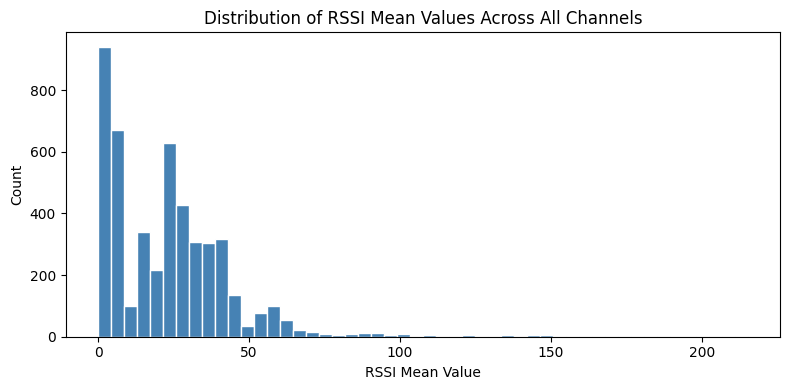


TARGET CHANNEL (rssi_temporal_B_b) STATUS
Busy : 60 (30.0%)
Idle : 140 (70.0%)


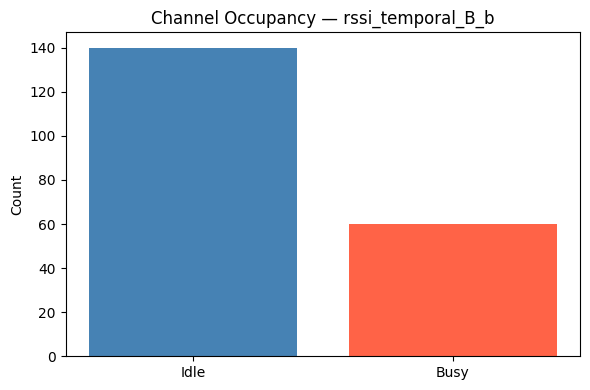

In [3]:
#RSSI Distribution
mean_cols = [c for c in df.columns if c.endswith('_mean')]
all_means  = df[mean_cols].values.flatten()
print("RSSI Mean Statistics:")
print(f"  Min:  {all_means.min():.2f}")
print(f"  Max:  {all_means.max():.2f}")
print(f"  Mean: {all_means.mean():.2f}")
print(f"  50th percentile: {np.percentile(all_means, 50):.2f}")
print(f"  75th percentile: {np.percentile(all_means, 75):.2f}")
plt.figure(figsize=(8, 4))
plt.hist(all_means, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of RSSI Mean Values Across All Channels')
plt.xlabel('RSSI Mean Value')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('rssi_distribution.png')
plt.show()
#Busy vs Idle distribution
busy_count = df['target_busy'].sum()
idle_count = 200 - busy_count
print(f"\nTARGET CHANNEL ({TARGET}) STATUS")
print(f"Busy : {busy_count} ({busy_count/200*100:.1f}%)")
print(f"Idle : {idle_count} ({idle_count/200*100:.1f}%)")
plt.figure(figsize=(6, 4))
plt.bar(['Idle', 'Busy'], [idle_count, busy_count],
        color=['steelblue', 'tomato'])
plt.title(f'Channel Occupancy — {TARGET}')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('busy_idle_final.png')
plt.show()